# The Fourth Circle: Neural Networks, Part Three 
## Recurrent Neural Networks I: Introduction

<br/>
Jiří Fejlek

2026-03-11
<br/>

## Table of Contents

- [Processing Raw Text Data](#raw_text)
    - [Tokens](#tokens)
    - [Vocabulary](#vocab)
    - [Zipf’s law](#zip)
    - [Dataloader Implementation](#dataloader)
- [Natural Language Model via Simple RNN](#nlm)
    - [Implementation of Simple RNN in PyTorch](#implement)
    - [Computations Inside Simple RNN Step by Step](#stepbystep)
    - [Training Simple RNN (prediction loss based on the last element in the sequence)](#losslast)
    - [Training Simple RNN (prediction loss based on the whole sequence)](#whole)
- [Deep Recurrent Neural Networks](#deep)
- [References](#references)


In the third part of the Fourth Circle, which is focused on the main neural network architectures, we will explore recurrent neural networks. Unlike convolutional neural networks, which were primarily designed to deal with images (we mainly explored image classification, but convolutional neural networks can also be employed for other computer vision tasks, such as object detection, image segmentation, object sharpening, and denoising), the main motivation in the development of recurrent neural network architectures is the processing of sequential data. One typical example of sequential data we could probably immediately think of are time series. Another crucial type of sequential data, which has become very prominent in machine learning in recent years thanks to the rise of large language models (LLMs), is text data. Consequently, similar to our introduction to convolutional neural network architectures, which we investigated through the prism of image classification, we will have a look at recurrent neural networks and primarily their application in *natural language processing* (NLP).  Natural language processing includes solving tasks such as text classification, sentiment analysis (aka opinion mining), machine translation, and text summarization.

In this first introductory part, we will introduce *a simple recurrent neural network* architecture, also known as the Elman Network [[1](#1)]. But before we do that, we also need to learn how to process raw text data into a form more suitable as input to a neural network. Lastly, we should note that this project is, by and large, based on Chapter 9 of *Dive into Deep Learning* [[2](#2)] (available online at https://d2l.ai).

## Processing Raw Text Data <a class="anchor" id="raw_text"></a>

Before we introduce a simple recurrent neural network for solving NLP tasks, we have to show how to prepare raw text data for further processing.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 3050 Laptop GPU'

Hence, we start with loading our raw text, namely *The Time Machine* by H. G. Wells (which we will use for the purpose of our demonstration in this project).

In [3]:
time_machine_text = open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()

In [4]:
time_machine_text[:1000]

"The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Traveller (for so it will be convenient to speak of him)\nwas expounding a recondite matter to us. His grey eyes shone and\ntwinkled, and his usually pale face was flushed and animated. The\nfire burned brightly, and the soft radiance of the incandescent\nlights in the lilies of silver caught the bubbles that flashed and\npassed in our glasses. Our chairs, being his patents, embraced and\ncaressed us rather than submitted to be sat upon, and there was that\nluxurious after-dinner atmosphere when thought roams gracefully\nfree of the trammels of precision. And he put it to us in this\nway--marking the points with a lean forefinger--as we sat and lazily\nadmired his earnestness over this new paradox (as we thought it)\nand his fecundity.\n\n'You must follow me carefully. I shall have to controvert one or two\nideas that are almost universally accepted. The geometry, for\ninstance, they taught you at school is founded on a 

### Tokens <a class="anchor" id="tokens"></a>

To prepare raw text for further processing, we will turn it into a sequence of *tokens*, indivisible units of text. Tokens could be, for example, characters or words. In practice, tokens are usually somewhere between: commonly used words are tokens themselves, and rarer words are split into multiple tokens. For example, the word important is a single token in  OpenAI's (authors of ChatGPT large language models) tokenizer (https://platform.openai.com/tokenizer), but the word unnecessarily is split into two tokens 'un' and 'necessarily'. And, for example, the quite ridiculous word antidisestablishmentarianism consists of six tokens: ant+idis+est+ablishment+arian+ism.

Let us implement our own tokenizer for The Time Machine book. For simplicity's sake, we will first convert upper cases to lower cases, and we will also ignore special characters (e.g., punctuation marks). Then, we will use words as our tokens.

In [5]:
class TimeMachine: 
    
    def _read(self): # read the text 
        return open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()
        
    def _preprocess(self, text): # replace special characters with ' ', convert upper cases to lower case
        return re.sub('[^A-Za-z]+', ' ', open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()).lower()

    def _tokenize(self, text): # convert text to a list of words
         return text.split()

In [6]:
time_machine_data = TimeMachine()
raw_text = time_machine_data._read()
raw_text[:1000]

"The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Traveller (for so it will be convenient to speak of him)\nwas expounding a recondite matter to us. His grey eyes shone and\ntwinkled, and his usually pale face was flushed and animated. The\nfire burned brightly, and the soft radiance of the incandescent\nlights in the lilies of silver caught the bubbles that flashed and\npassed in our glasses. Our chairs, being his patents, embraced and\ncaressed us rather than submitted to be sat upon, and there was that\nluxurious after-dinner atmosphere when thought roams gracefully\nfree of the trammels of precision. And he put it to us in this\nway--marking the points with a lean forefinger--as we sat and lazily\nadmired his earnestness over this new paradox (as we thought it)\nand his fecundity.\n\n'You must follow me carefully. I shall have to controvert one or two\nideas that are almost universally accepted. The geometry, for\ninstance, they taught you at school is founded on a 

In [7]:
text = time_machine_data._preprocess(raw_text)
text[:1000]

'the time machine by h g wells i the time traveller for so it will be convenient to speak of him was expounding a recondite matter to us his grey eyes shone and twinkled and his usually pale face was flushed and animated the fire burned brightly and the soft radiance of the incandescent lights in the lilies of silver caught the bubbles that flashed and passed in our glasses our chairs being his patents embraced and caressed us rather than submitted to be sat upon and there was that luxurious after dinner atmosphere when thought roams gracefully free of the trammels of precision and he put it to us in this way marking the points with a lean forefinger as we sat and lazily admired his earnestness over this new paradox as we thought it and his fecundity you must follow me carefully i shall have to controvert one or two ideas that are almost universally accepted the geometry for instance they taught you at school is founded on a misconception is not that rather a large thing to expect us t

In [8]:
tokens = time_machine_data._tokenize(text)
','.join(tokens[:100])

'the,time,machine,by,h,g,wells,i,the,time,traveller,for,so,it,will,be,convenient,to,speak,of,him,was,expounding,a,recondite,matter,to,us,his,grey,eyes,shone,and,twinkled,and,his,usually,pale,face,was,flushed,and,animated,the,fire,burned,brightly,and,the,soft,radiance,of,the,incandescent,lights,in,the,lilies,of,silver,caught,the,bubbles,that,flashed,and,passed,in,our,glasses,our,chairs,being,his,patents,embraced,and,caressed,us,rather,than,submitted,to,be,sat,upon,and,there,was,that,luxurious,after,dinner,atmosphere,when,thought,roams,gracefully,free,of'

### Vocabulary <a class="anchor" id="vocab"></a>

As the next step, we will create a *vocabulary*, a list of all tokens. We need to add a special token for an unknown token to the list, in case we encounter a word that is not in our vocabulary. 

The following class *Vocabulary* builds a vocabulary from the list of tokens (it discards tokens from the vocabulary provided that their occurrence in the text is lower than *min_freq*). It also includes the function  *\_\_getitem\_\_* that assigns an index value of the corresponding token to every word in a list and  *to_tokens* that converts a list of indices back to tokens, i.e., words. The function *\_\_len\_\_* simply returns the number of tokens in the vocabulary.

In [9]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

Let use create a vocabulary from the tokens in The Time Machine.

In [10]:
time_machine_vocab = Vocabulary(tokens)

The token/word frequencies in text are as follows.

In [11]:
time_machine_vocab.token_freqs[:25]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440),
 ('it', 437),
 ('had', 354),
 ('me', 281),
 ('as', 270),
 ('at', 243),
 ('for', 221),
 ('with', 216),
 ('but', 204),
 ('time', 200),
 ('were', 158),
 ('this', 152),
 ('you', 137),
 ('on', 137),
 ('then', 134),
 ('his', 129)]

Our vocabulary consists of 4580 tokens.

In [12]:
time_machine_vocab.__len__()

4580

We can obtain indices for the tokens as follows (note that the word car is not in the vocabulary, so it is represented by the token "unknown").

In [13]:
time_machine_vocab.__getitem__(['the','a','with','<unk>','car'])

[4041, 1, 4503, 0, 0]

We get tokens from indices as follows.

In [14]:
time_machine_vocab.to_tokens([4041, 1, 4503, 0, 0])

['the', 'a', 'with', '<unk>', '<unk>']

Consequently, the beginning of The Time Machine is the following sequence of tokens.

In [15]:
indices = time_machine_vocab[tokens[:100]]
print('indices:', indices)

indices: [4041, 4108, 2414, 504, 1807, 1657, 4444, 1992, 4041, 4108, 4167, 1568, 3690, 2182, 4488, 319, 795, 4118, 3735, 2730, 1921, 4401, 1365, 1, 3200, 2464, 4118, 4298, 1925, 1769, 1383, 3545, 138, 4224, 138, 1925, 4304, 2821, 1386, 4401, 1542, 138, 150, 4041, 1483, 489, 459, 138, 4041, 3696, 3140, 2730, 4041, 2045, 2342, 2038, 4041, 2347, 2730, 3596, 563, 4041, 481, 4040, 1512, 138, 2854, 2038, 2778, 1716, 2778, 583, 353, 1925, 2860, 1245, 138, 537, 4298, 3160, 4038, 3896, 4118, 319, 3395, 4291, 138, 4050, 4401, 4040, 2410, 72, 1048, 256, 4454, 4076, 3342, 1742, 1612, 2730]


In [16]:
print('words:', time_machine_vocab.to_tokens(indices))

words: ['the', 'time', 'machine', 'by', 'h', 'g', 'wells', 'i', 'the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him', 'was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and', 'twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the', 'fire', 'burned', 'brightly', 'and', 'the', 'soft', 'radiance', 'of', 'the', 'incandescent', 'lights', 'in', 'the', 'lilies', 'of', 'silver', 'caught', 'the', 'bubbles', 'that', 'flashed', 'and', 'passed', 'in', 'our', 'glasses', 'our', 'chairs', 'being', 'his', 'patents', 'embraced', 'and', 'caressed', 'us', 'rather', 'than', 'submitted', 'to', 'be', 'sat', 'upon', 'and', 'there', 'was', 'that', 'luxurious', 'after', 'dinner', 'atmosphere', 'when', 'thought', 'roams', 'gracefully', 'free', 'of']


Lastly, we will include building a vocabulary as a part of our *TimeMachine* data class.

In [17]:
class TimeMachine: 
    
    def _read(self): # read the text 
        return open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()
        
    def _preprocess(self, text): # replace special characters with ' ', convert upper cases to lower case
        return re.sub('[^A-Za-z]+', ' ', open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()).lower()

    def _tokenize(self, text): # convert text to a list of words
         return text.split()
        
    def _build(self, raw_text, vocab=None):
        tokens = self._tokenize(self._preprocess(raw_text))
        if vocab is None: 
            vocab = Vocabulary(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab

Overall, we transformed our raw text into two objects: vocabulary and the text itself, represented as a sequence of tokens, known as a *corpus*. 

In [18]:
time_machine_data = TimeMachine()
time_machine_corpus, time_machine_vocab = time_machine_data._build(time_machine_data._read())

In [19]:
time_machine_vocab.to_tokens(time_machine_corpus[:10])

['the', 'time', 'machine', 'by', 'h', 'g', 'wells', 'i', 'the', 'time']

In [20]:
time_machine_corpus[:10]

[4041, 4108, 2414, 504, 1807, 1657, 4444, 1992, 4041, 4108]

###  Zipf’s Law <a class="anchor" id="zip"></a>

Before we move on, let us return to the observed frequencies of tokens (i.e., words)  in the text.

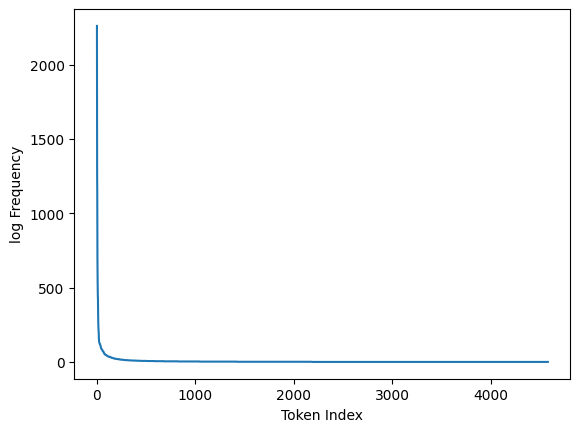

In [21]:
plt.plot(range(1,len(time_machine_vocab.token_freqs)+1), [freq for token, freq in time_machine_vocab.token_freqs]);
plt.xlabel('Token Index')
plt.ylabel('log Frequency');

We notice that the frequency of the most common words in the text is much higher than the frequency of the rarer words. The nature of this relationship can be better seen on a logarithmic scale. 

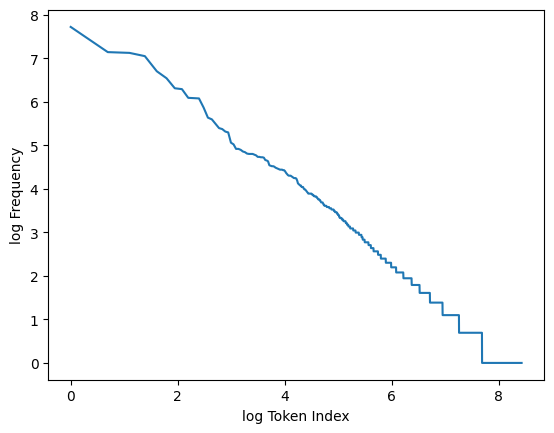

In [22]:
plt.plot(np.log(range(1,len(time_machine_vocab.token_freqs)+1)), np.log([freq for token, freq in time_machine_vocab.token_freqs]));
plt.xlabel('log Token Index')
plt.ylabel('log Frequency');

We observe that the relationship between the log of frequencies and the log of the rank is almost linear, i.e.,
$$\text{log } n_i \approx -\alpha\, \text{log}\,i + \text{const.}.$$
In other words,
$$n_i \varpropto  \frac{1}{i^\alpha}.$$
This empirical relationship, known as Zipf’s law [[2](#2)], and it does not hold only for single words. If we have a look at sequences of two words (bigrams), and sequences of three words (trigrams) ..., we will notice a similar relationship.

In [23]:
words = text.split()
bigram_tokens = ['--'.join(pair) for pair in zip(words[:], words[1:])]
bigram_vocab = Vocabulary(bigram_tokens)
bigram_vocab.token_freqs[:10]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109),
 ('the--time', 102),
 ('it--was', 99),
 ('to--the', 85),
 ('as--i', 78),
 ('of--a', 73)]

In [24]:
trigram_tokens = ['--'.join(triple) for triple in zip(
words[:], words[1:], words[2:])]
trigram_vocab = Vocabulary(trigram_tokens)
trigram_vocab.token_freqs[:10]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13)]

In [25]:
fourgram_tokens = ['--'.join(quadruple) for quadruple in zip(
words[:], words[1:], words[2:], words[3:])]
fourgram_vocab = Vocabulary(fourgram_tokens)
fourgram_vocab.token_freqs[:10]

[('said--the--time--traveller', 12),
 ('said--the--medical--man', 11),
 ('it--seemed--to--me', 11),
 ('palace--of--green--porcelain', 8),
 ('the--time--machine--and', 7),
 ('as--i--did--so', 7),
 ('the--palace--of--green', 7),
 ('the--time--traveller--s', 6),
 ('of--the--time--machine', 6),
 ('the--time--machine--i', 6)]

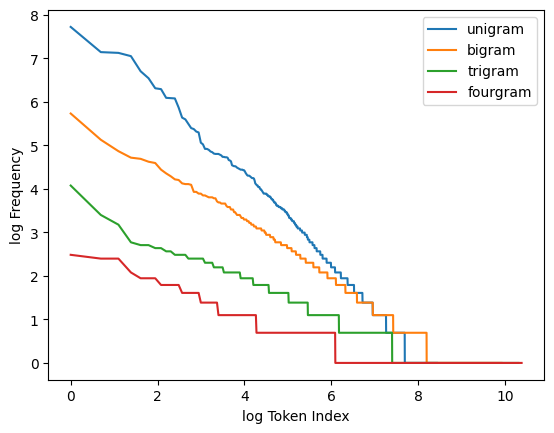

In [26]:
plt.plot(np.log(range(1,len(time_machine_vocab.token_freqs)+1)), np.log([freq for token, freq in time_machine_vocab.token_freqs]), label="unigram")
plt.plot(np.log(range(1,len(bigram_vocab.token_freqs)+1)), np.log([freq for token, freq in bigram_vocab.token_freqs]), label="bigram")
plt.plot(np.log(range(1,len(trigram_vocab.token_freqs)+1)), np.log([freq for token, freq in trigram_vocab.token_freqs]), label="trigram")
plt.plot(np.log(range(1,len(fourgram_vocab.token_freqs)+1)), np.log([freq for token, freq in fourgram_vocab.token_freqs]), label="fourgram")

plt.xlabel('log Token Index')
plt.ylabel('log Frequency')
plt.legend();

This observation shows that natural language is highly structured, enabling the statistical modeling of text data.

###  Dataloader Implementation <a class="anchor" id="dataloader"></a>

As the last step, we will implement a dataloader for our text dataset. But to do so, we need to specify the task. Let us assume a sequence of tokens. Our goal will be to create a model that predicts the next token for each such sequence. Hence, our training and test datasets will consist of sequences extracted from the corpus. More specifically, we create a dataset of sequences of length *num_steps*.

In [27]:
class TimeMachine: 
    
    def _read(self): # read the text 
        return open('C:/Users/elini/Desktop/nine circles 2/timemachine.txt').read()
        
    def _preprocess(self, text): # replace special characters with ' ', convert upper cases to lower case
        return re.sub('[^A-Za-z]+', ' ', open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()).lower()

    def _tokenize(self, text): # convert text to a list of words
         return text.split()
        
    def _build(self, raw_text, vocab=None): # built vocabulary
        tokens = self._tokenize(self._preprocess(raw_text))
        if vocab is None: 
            vocab = Vocabulary(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab
        
    ################################
    
    def __init__(self, batch_size, num_steps, num_train = 10000, num_test = 5000):  

        self.batch_size = batch_size
        self.num_train = num_train
        self.num_test = num_test
        
        corpus, self.vocab = self._build(self._read()) # build vocabulary
        array = torch.tensor([corpus[i:i+num_steps+1] for i in range(len(corpus)-num_steps)]) # extract sequences from the text
        self.X, self.Y = array[:,:-1], array[:,1:] # Y is shifted by one index

    
    # dataloader
    def get_dataloader(self, train): 
        # sequences till num_train are from the train set, the latter are from the test set 
        idx = slice(0, self.num_train) if train else slice(self.num_train, self.num_train + self.num_test) 
        return self.get_tensorloader([self.X, self.Y], train, idx)
        
    def train_dataloader(self):
        return self.get_dataloader(train=True)
        
    def test_dataloader(self):
        return self.get_dataloader(train=False)
        
    # we will simply use the dataloader from torch
    def get_tensorloader(self, tensors, train, indices=slice(0, None)):
        tensors = tuple(a[indices] for a in tensors) # get train/test sequences based on idx
        dataset = torch.utils.data.TensorDataset(*tensors) 
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)    

In [28]:
TimeMachine_data = TimeMachine(batch_size=1, num_steps=10)

The inputs $X$ for our model will consist of all n-grams ($n$ = *num_steps*) in The Time Machine. Notice that the target outputs $Y$ are the same  n-gram shifted by one, i.e., we seek to predict the second token from the first token in each n-gram, the third token from the first two tokens, and so on. The final predictions for each n-gram are predictions of the $(n+1)$th tokens from the whole n-gram.

In [29]:
TimeMachine_data.X

tensor([[4041, 4108, 2414,  ..., 1992, 4041, 4108],
        [4108, 2414,  504,  ..., 4041, 4108, 4167],
        [2414,  504, 1807,  ..., 4108, 4167, 1568],
        ...,
        [1754,  138,    1,  ..., 2740, 2038, 4041],
        [ 138,    1, 2607,  ..., 2038, 4041, 1879],
        [   1, 2607, 4022,  ..., 4041, 1879, 2730]])

In [30]:
TimeMachine_data.Y

tensor([[4108, 2414,  504,  ..., 4041, 4108, 4167],
        [2414,  504, 1807,  ..., 4108, 4167, 1568],
        [ 504, 1807, 1657,  ..., 4167, 1568, 3690],
        ...,
        [ 138,    1, 2607,  ..., 2038, 4041, 1879],
        [   1, 2607, 4022,  ..., 4041, 1879, 2730],
        [2607, 4022, 3828,  ..., 1879, 2730, 2433]])

As usual, we will split the dataset into the training dataset and test dataset (the size is given by *num_train* and *num_test*)

In [31]:
for X, Y in TimeMachine_data.train_dataloader():
    print('X:', X, '\nY:', Y)
    break

X: tensor([[2469, 2742, 2730, 4044,   48, 2469, 2182,  517, 2160, 2608]]) 
Y: tensor([[2742, 2730, 4044,   48, 2469, 2182,  517, 2160, 2608, 1866]])


In [32]:
for X, Y in TimeMachine_data.test_dataloader():
    print('X:', X, '\nY:', Y)
    break

X: tensor([[1992, 1812, 1740, 2744,    1, 1821, 4200, 2762, 2744,    1]]) 
Y: tensor([[1812, 1740, 2744,    1, 1821, 4200, 2762, 2744,    1, 1725]])


## Natural Language Model via Simple RNN<a class="anchor" id="nlm"></a>

Having converted the raw text from the Time Machine into a dataset of token sequences (n-grams), let us now create a model to predict the next token in these n-grams. Let us assume an n-gram $(x_1, x_2, x_3, \ldots, x_n)$. We will assume a probability model with the Markov property [[2](#2)], which allows probability factorization 
$$ P(x_1, x_2, \ldots, x_n) = P(x_1)P(x_2 \mid x_1)P(x_3 \mid x_1, x_2) \ldots P(x_n \mid x_1, \ldots, x_n),$$
i.e., a value of an element in a sequence depends only on its past.

Now, we will simplify this model a bit. Since n-grams could be quite long, it would be impractical to always remember the whole sequence. Instead, we will consider a *latent* variable model
$$P(x_i \mid x_1, x_2, \ldots, x_{i-1}) \approx P(x_i \mid h_{i-1}),$$
where $h_{i-1}$ is known as a *hidden state*. The hidden state represents the model's memory of what came before in the sequence. The hidden state can be computed as 
$$h_i = f(x_i, h_{i-1}).$$
This is a *recurrent* computation; hence, neural networks with hidden states are known as recurrent neural networks (RNNs). Namely, let us assume a neural network which we will refer to as a simple RNN (or the Elman Network [[1](#1)] proposed in 1990). The hidden state at step $t$ is given by a single hidden layer as
$$h_t = \phi(W_{xh}x_t + W_{hh}h_{t-1} + b_h),$$
where $\phi$ is an activation function, $x_t$ is the $t$th element of the sequence, $W_{xh}$ and $W_{hh}$ are matrices of weights, and $b_h$ is a bias vector. 

The final output of the whole network is given as
$$y_t =  W_{hq}h_t + b_q,$$
where again $W_{hq}$ are some weights and $h_t$ is bias. Hence, we get the following schema of a simple RNN [[2](#2)].

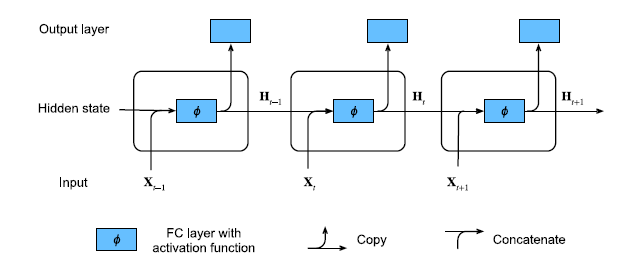

We observe that our recurrent neural network is very similar to a standard feedforward neural network, except for the inclusion of a hidden state, and that computation is performed sequentially, rather than in a single pass. 

### Implementation of Simple RNN in PyTorch <a class="anchor" id="implement"></a>

Let us implement the simple RNN in PyTorch. The RNN block used for computing the hidden state is implemented in PyTorch as *nn.RNN*. We can specify the number of hidden layers and the activation function (by default, there is one hidden layer and the tanh activation function). 

We will first follow the approach in [[2](#2)] and build a simple RNN to predict the next element in a given sequence.  

In [33]:
class RNN_Model(nn.Module):

    def __init__(self, num_hiddens, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        
        self.rnn = nn.RNN(vocab_size, num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((1, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32) # one-hot encode input 
        Y, state = self.rnn(X, state)
        Y_last = Y[-1]

        output = self.linear(Y_last)
        return output, state

We should comment on the implementation a bit. First, the model's inputs are the sequence itself and the value of the hidden state (if the model maintains prior memory). Provided that the model has no memory, we need to specify the initial value of the hidden state, which we set as a tensor of zeros. The dimensionality of the hidden state (*num_layers x batch_size x num_hiddens*) is given in the documentation of *nn.RNN*. 

Next, we need to consider the fact that our sequences consist of tokens, i.e., categorical variables. Hence, we need to encode the token values. We use one-hot encoding for that purpose. The one-hot encoded sequence of tokens and the hidden state are fed into the recurrent block, which returns the new value of the hidden state and the output sequence *Y* (we will use only the last value since we are, for now, interested merely in the prediction of the next element in the sequence). We should note that the output sequence *Y* is simply the evolution of the hidden states over time (in general, it is the evolution of the hidden states of the last layer).

Lastly, we feed *Y_last* into the linear layer, which transforms it into probability logits, from which we obtain probability predictions for the value of the next token in the sequence.

### Computations Inside Simple RNN Step by Step <a class="anchor" id="stepbystep"></a>

It will probably be illustrative to perform the whole calculation step by step to get a better feeling for what is actually going on. Let us initialize our data loaders. As usual, we will feed the sequences of the length *num_steps* = 10 into the model in batches *batch_size* = 1000.

In [34]:
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()

Next, we initialize the recurrent layer *rnn* (input dimension is given by vocabulary size and the output is given by the number of neurons in the hidden layer *num_hiddens*) and the linear layer *linear*.

In [35]:
rnn = nn.RNN(TimeMachine_data.vocab.__len__(), 32)
linear = nn.Linear(32,TimeMachine_data.vocab.__len__())

Our first batch of the training sequences is as follows.

In [36]:
for X, Y in TimeMachine_train_loader:
    print('X:', X, '\nY:', Y)
    break

X: tensor([[4041, 2858, 1992,  ..., 2239, 4459,   72],
        [ 138, 2038, 4041,  ..., 2182,  100, 3462],
        [2038, 2377, 1568,  ..., 1237, 3145, 4050],
        ...,
        [4488, 1475,  684,  ..., 3914, 4041, 1976],
        [1608, 2064, 4041,  ..., 4401, 4072, 4108],
        [3056,  138, 4041,  ..., 4018, 4140, 3214]]) 
Y: tensor([[2858, 1992, 1110,  ..., 4459,   72,  132],
        [2038, 4041,  749,  ...,  100, 3462, 4118],
        [2377, 1568, 2117,  ..., 3145, 4050,  204],
        ...,
        [1475,  684, 4118,  ..., 4041, 1976, 2730],
        [2064, 4041, 1217,  ..., 4072, 4108, 4168],
        [ 138, 4041, 2059,  ..., 4140, 3214, 1810]])


In [37]:
X.size()

torch.Size([1000, 10])

In [38]:
Y.size()

torch.Size([1000, 10])

As we mentioned earlier, we need to one-hot encode the inputs. Consequently, the actual input to the neural network is as follows (each token is represented by a vector of zeros with a single one at the corresponding index).

In [39]:
X_one_hot = F.one_hot(X.T.long(), TimeMachine_data.vocab.__len__()).to(torch.float32)
X_one_hot.size()

torch.Size([10, 1000, 4580])

We do not assume that the model has any prior memory before each input sequence, hence the hidden state is initialized to zeros (to determine dimensionality, we follow the prescription num_layers x batch_size x num_hiddens).

In [40]:
state = torch.zeros((1, X.shape[0], 32))
state.size()

torch.Size([1, 1000, 32])

Next, we can compute the output from the recurrent block.

In [41]:
Y_pred, state = rnn(X_one_hot,state)

The output sequences have the following dimensionality.

In [42]:
Y_pred.size()

torch.Size([10, 1000, 32])

We observe that we get 1000 (the number of batches) sequences of length 10 (the length of input sequences) of vectors of dimension 32 (the number of neurons in the hidden layer). The new hidden state has naturally the same dimensionality as the old one.

In [43]:
state.size()

torch.Size([1, 1000, 32])

Since we are interested merely in the last state, we wil extract merely the last tensor (wrt. the first dimension).

In [44]:
Y_pred_last = Y_pred[-1]
Y_pred_last.size()

torch.Size([1000, 32])

We can see that *Y_pred_last* is simply the current value of the hidden state; i.e., the recurrent layers' outputs *Y_pred* is simply a history of hidden states.

In [45]:
Y_pred_last

tensor([[-0.1850, -0.0903, -0.0863,  ...,  0.0954, -0.2592, -0.2458],
        [-0.3759,  0.1359, -0.2026,  ...,  0.2174, -0.1980, -0.1739],
        [-0.3261,  0.0073, -0.2323,  ...,  0.2357,  0.0283, -0.0111],
        ...,
        [-0.3406, -0.2140, -0.3511,  ...,  0.3168, -0.1664, -0.1160],
        [-0.2450,  0.2211, -0.3542,  ...,  0.0075, -0.0447, -0.2228],
        [-0.2705, -0.1369, -0.1277,  ...,  0.2173, -0.1920, -0.2260]],
       grad_fn=<SelectBackward0>)

In [46]:
state

tensor([[[-0.1850, -0.0903, -0.0863,  ...,  0.0954, -0.2592, -0.2458],
         [-0.3759,  0.1359, -0.2026,  ...,  0.2174, -0.1980, -0.1739],
         [-0.3261,  0.0073, -0.2323,  ...,  0.2357,  0.0283, -0.0111],
         ...,
         [-0.3406, -0.2140, -0.3511,  ...,  0.3168, -0.1664, -0.1160],
         [-0.2450,  0.2211, -0.3542,  ...,  0.0075, -0.0447, -0.2228],
         [-0.2705, -0.1369, -0.1277,  ...,  0.2173, -0.1920, -0.2260]]],
       grad_fn=<StackBackward0>)

To obtain our predictions from the hidden states, we need to transform them into probability logits using the linear layer.

In [47]:
logits_last = linear(Y_pred_last)
logits_last.size()

torch.Size([1000, 4580])

In [48]:
logits_last

tensor([[ 0.0698, -0.0115, -0.0463,  ..., -0.2022, -0.2270, -0.0352],
        [ 0.0234, -0.0756, -0.2161,  ..., -0.2683, -0.1277, -0.0393],
        [ 0.1080, -0.0445, -0.2111,  ..., -0.2667, -0.1983, -0.0096],
        ...,
        [ 0.0089,  0.0365, -0.1759,  ..., -0.1441, -0.1206, -0.0663],
        [ 0.0408, -0.0152, -0.1928,  ..., -0.1365, -0.1191, -0.1045],
        [-0.0066, -0.0832, -0.1453,  ..., -0.2608, -0.0443,  0.0311]],
       grad_fn=<AddmmBackward0>)

We can then compare the obtained logits with the actual observed tokens. As usual, we will use cross-entropy for this purpose.

In [49]:
loss = nn.CrossEntropyLoss()
Y_last = Y[:,-1]
loss(logits_last, Y_last)

tensor(8.4306, grad_fn=<NllLossBackward0>)

All the previous steps can be performed using our *RNN_Model* simply as follows.

In [50]:
RNN_simple_net = RNN_Model(num_hiddens = 32, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)

In [51]:
logit_pred, state = RNN_simple_net(X.to(cuda_device))

In [52]:
logit_pred.size()

torch.Size([1000, 4580])

In [53]:
loss(logit_pred, Y_last.to(cuda_device))

tensor(8.4665, device='cuda:0', grad_fn=<NllLossBackward0>)

### Training Simple RNN (prediction loss based on the last element in the sequence) <a class="anchor" id="losslast"></a>

All that remains is to write the training/test loop. The code is very similar to the one we used to train feedforward convolutional neural networks. One slight difference is the inclusion of *gradient clipping* via *torch.nn.utils.clip_grad_norm_*, which controls the value of the gradient by bounding its norm by some chosen constant. This step is included because, due to the recurrent nature of RNN computations, the magnitudes of gradients tend to explode (or vanish), making RNN training notoriously more challenging than that of feedforward neural networks.

In [54]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)

        y_last = y[:, -1]
        y_last = y_last.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits, state = model(X) # forward pass
        
        loss = loss_fn(pred_logits, y_last) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            y_test_last = y_test[:,-1]
            y_test_last = y_test_last.to(cuda_device)
            
            pred_logits_test, state = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test_last)*len(X_test)
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

Finally, we can train our RNN on the text of The Time Machine. As we mentioned earlier, the outputs of our RNN are the probability logits for the next token in the sequence. Hence, we can simply use the cross-entropy as our loss function.

In [55]:
torch.manual_seed(123)

# data loader
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()


# googlenet initialization
RNN_simple_net_cuda = RNN_Model(num_hiddens = 64, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)


optim_SGD_cuda =  torch.optim.SGD(RNN_simple_net_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(TimeMachine_train_loader, TimeMachine_test_loader, RNN_simple_net_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)


65.17793583869934


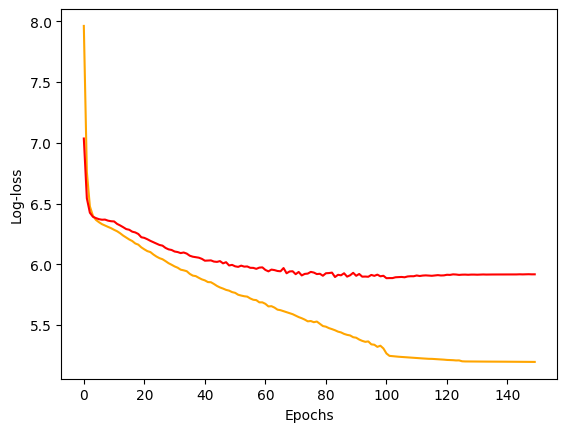

In [56]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

To get a better idea of what the training actually accomplished, let us write a simple prediction function that takes raw text as input and iteratively extends it with the most probable tokens according to our language model (aka the *greedy* prediction strategy), i.e., tokens are predicted one at a time.

In [57]:
def predict(model, prefix, num_preds, vocab, device):
    prefix = prefix.split()
    prefix = torch.tensor([vocab.__getitem__(prefix)]).to(cuda_device)
    state = None

    for i in range(num_preds):
        Y_pred, state = model(prefix, state)
        prefix = torch.cat((prefix[0],Y_pred.argmax()[None]),0)[None,:]

    predicted_text = vocab.to_tokens(prefix[0].tolist())
    delimeter = ' '
        
    return delimeter.join(predicted_text)

In [58]:
predict(RNN_simple_net_cuda, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was not the time traveller and the little man was not the time traveller and the little man was not the'

In [59]:
predict(RNN_simple_net_cuda, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am not a little time and i was a little of the time traveller was a little thing i had not'

In [60]:
predict(RNN_simple_net_cuda, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword of time i had not a little of the time traveller was a little thing i had not a little'

We observe that our model is not that great. It quickly devolves into repeating the same tokens over and over. We have to keep in mind that our model is very simple, and the amount of text we used to train it is laughably small compared to the data used to train language models nowadays (essentially all the text data available on the internet). 

### Training Simple RNN (prediction loss based on the whole sequence) <a class="anchor" id="whole"></a>

As the last step of this introductory project, let us try to do a bit better. During training, we evaluated our loss based on the last predicted token. Let us now use the whole sequence instead. We will also evaluate the "intermediate" predictions (the second token from the first, the third from the first, and so on).The cross-entropy loss for a given sequence $(x_1, x_2, \ldots, x_n)$ is then
$$- \frac{1}{n}\sum_{i = 2}^{n} \text{log }P(x_{i} | x_1, x_2, \ldots, x_{i-1}).$$
We should note that the associated measure of predictions of language models is *perplexity*, which is simply defined as [[2](#2)]
$$PP = \text{exp }\left(- \frac{1}{n}\sum_i^n P(x_i | x_1, x_2, \ldots, x_{i-1})\right).$$


We get the following simple observations about perplexity from its definition
- $P(x_i | x_1, x_2, \ldots, x_{i-1}) = 1 $ for the true value of the token $\rightarrow$  perplexity equals 1
- $P(x_i | x_1, x_2, \ldots, x_{i-1}) = 0 $ for the true value of the token $\rightarrow$  perplexity equals positive infinity
- $P(x_i | x_1, x_2, \ldots, x_{i-1}) \sim \text{Uniform}$ for all $i$ $\rightarrow$ perplexity equals number of unique tokens of the vocabulary


Let us train our model using perplexity. We need to make merely a slight change to the code.

In [61]:
class RNN_Model_2(nn.Module):

    def __init__(self, num_hiddens, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        
        self.rnn = nn.RNN(vocab_size, num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((1, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32) # one-hot encode input 
        Y, state = self.rnn(X, state)

        output = self.linear(Y)
        return output, state

We should note that when evaluating *nn.CrossEntropyLoss()*, we need to use the order: batch size x number of categories x input dimensions. Hence, we need to reorder the outputs using the *permute* function.  

In [62]:
def train_test_loop_cuda_2(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits, state = model(X) # forward pass
        
        loss = loss_fn(pred_logits.permute(1, 2, 0), y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test, state = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test.permute(1, 2, 0), y_test)*len(X_test)
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

In [63]:
torch.manual_seed(123)

# data loader
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()

RNN_simple_net_cuda2 = RNN_Model_2(num_hiddens = 64, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(RNN_simple_net_cuda2.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda_2(TimeMachine_train_loader, TimeMachine_test_loader, RNN_simple_net_cuda2, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

167.06361842155457


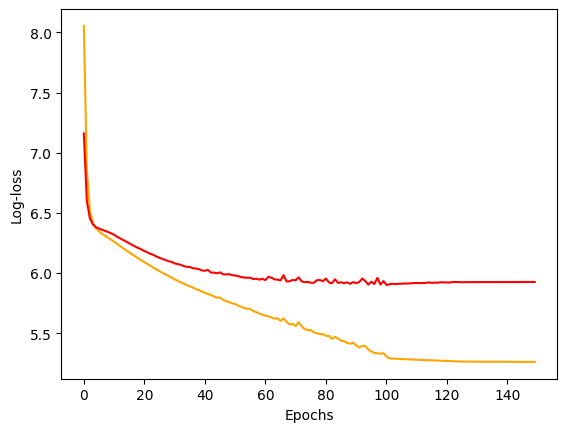

In [64]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

Let us have a look at the predictions of our second model.

In [65]:
def predict2(model, prefix, num_preds, vocab, device):
    prefix = prefix.split()
    prefix = torch.tensor([vocab.__getitem__(prefix)]).to(cuda_device)
    state = None

    for i in range(num_preds):
        Y_pred, state = model(prefix, state)
        Y_pred = Y_pred[-1,::]
        prefix = torch.cat((prefix[0],Y_pred.argmax()[None]),0)[None,:]

    predicted_text = vocab.to_tokens(prefix[0].tolist())
    delimeter = ' '
        
    return delimeter.join(predicted_text)

In [66]:
predict(RNN_simple_net_cuda, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was not the time traveller and the little man was not the time traveller and the little man was not the'

In [67]:
predict2(RNN_simple_net_cuda2, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was to a little of the time traveller had been a little of the world i had been to the time'

In [68]:
predict(RNN_simple_net_cuda, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am not a little time and i was a little of the time traveller was a little thing i had not'

In [69]:
predict2(RNN_simple_net_cuda2, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am to the time traveller and i had a little little of the time traveller was a little man and the'

In [70]:
predict(RNN_simple_net_cuda, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword of time i had not a little of the time traveller was a little thing i had not a little'

In [71]:
predict2(RNN_simple_net_cuda2, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword of time i had not a little of the world i had been to the time traveller and i had'

We observe that the differences between our models are quite small," both devolved rather quickly to repeating the same pattern of tokens. 

## Deep Recurrent Neural Networks <a class="anchor" id="deep"></a>

Up to this point, we trained simple RNNs with a single recurrent layer. Now, this single-layer RNN is actually deep in the sense that the input sequence passes through the network multiple times. Still, we may need a model with more complex relationships between the inputs and the hidden state using multiple recurrent layers. The standard approach to constructing deep RNNs is quite simple. We stack recurrent layers on top of each other: the outputs of one layer serve as inputs to the next [[2](#2)].

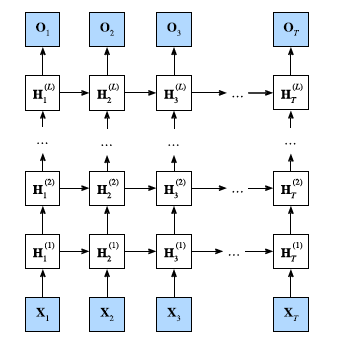

As for implementation, we simply increase the number of layers in *nn.RNN* using the parameter *num_layers*. We should also note that we need to increase the size of the hidden state tensor accordingly.

In [72]:
class RNN_Model_deep(nn.Module):

    def __init__(self, num_hiddens, num_layers, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(vocab_size, num_hiddens, num_layers)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((self.num_layers, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32) # one-hot encode input 
        Y, state = self.rnn(X, state)

        output = self.linear(Y)
        return output, state

In [73]:
torch.manual_seed(123)

# data loader
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()

RNN_simple_net_cuda3 = RNN_Model_deep(num_hiddens = 64, num_layers = 3, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(RNN_simple_net_cuda2.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda_2(TimeMachine_train_loader, TimeMachine_test_loader, RNN_simple_net_cuda2, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

173.89571380615234


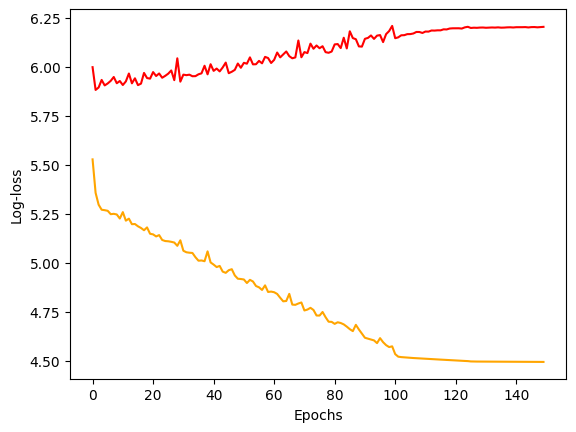

In [74]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [75]:
predict2(RNN_simple_net_cuda3, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was minerals spun obstacle vapour spun remarked motives uncut love spun motives spun uncut spun spun spun motives uncut spun spun'

In [76]:
predict2(RNN_simple_net_cuda2, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am not a little man were not a little of the world i had seen was the little people i had'

In [77]:
predict2(RNN_simple_net_cuda2, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword of space for that the time traveller s my mind i was the same man of a man i saw'

As with convolutional neural networks, the development of RNNs did not stop with the Elman Network. Hence, in the next projects, we will have a look at more modern RNN architectures, starting with Long Short-Term Memory (LSTM). 

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> ELMAN, Jeffrey L. Finding structure in time. *Cognitive science*, 1990, 14.2: 179-211.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.